In [1]:
import pandas as pd
import scanpy as sc
import numpy as np
import scipy.sparse as sp
import os
import seaborn as sns
import matplotlib.ticker as mticker

from datetime import datetime

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)


In [2]:
hiha_genes_df = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/genes.csv")
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/10_integration_GBM_HIHA/gbmap_hiha_concat_harmony.h5ad")

In [3]:
print(hiha_genes_df.columns.tolist())

['gene', 'mp', 'score']


In [4]:
print(adata.obs_keys)
print(adata.var_names[:10].tolist())
print(adata.var_names.str.startswith("ENSG").sum())  
print(adata.X.max())  # should be roughly 0–10 if log-normalized; hundreds/thousands if raw

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 208945 × 22586
    obs: 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level1_score', 'decoupler_level2_celltype', 'decoupler_level2_score', 'dataset', 'dataset_batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'dataset_colors', 'decoupler_level1_celltype_colors', 'hvg'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_preharmony', 'level1_padj_wsum', 'level1_score_wsum', 'level2_padj_wsum', 'level2_score_wsum'>
['ZNF470-DT', 'EN

In [3]:
import re
import matplotlib.pyplot as plt

BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/10_integration_GBM_HIHA"
os.makedirs(OUT_DIR, exist_ok=True)

In [4]:
MP_PALETTE_HIHA_ALT = {
    "MP1": "#0caece",  # 
    "MP2": "#946da1",  # 
    "MP3": "#90e0ef",  # 
    "MP4": "#00c39f",  # 
    "MP5": "#655fdc",  # 
    "MP6": "#4cd276",  # 
    "MP7": "#6B157A",  # 
    # "MP8": "#939393",  # 
}

### 1 - overlap test genes of MP with adata

In [5]:
overlap_records = []
for mp in hiha_genes_df["mp"].unique():
    mp_genes = hiha_genes_df.loc[hiha_genes_df["mp"] == mp, "gene"].tolist()
    n_total = len(mp_genes)
    n_present = sum(g in adata.var_names for g in mp_genes)
    overlap_records.append({
        "mp": mp,
        "n_total_genes": n_total,
        "n_present_genes": n_present,
        "pct_overlap": n_present / n_total if n_total > 0 else 0.0,
    })

overlap_df = pd.DataFrame(overlap_records).sort_values("pct_overlap")
print(overlap_df.to_string(index=False))

 mp  n_total_genes  n_present_genes  pct_overlap
MP4             57               55     0.964912
MP8            372              366     0.983871
MP7             77               76     0.987013
MP1             74               74     1.000000
MP3             15               15     1.000000
MP2             14               14     1.000000
MP6             18               18     1.000000
MP5             38               38     1.000000


In [9]:
print(adata.var_names.duplicated().sum())

0


#### score Healthy MPs onto integrated dateset

In [6]:
min_overlap = 0.5  # not really needed given your results, but keep as a safety net
mps_to_score = overlap_df.loc[overlap_df["pct_overlap"] >= min_overlap, "mp"].tolist()

for mp in mps_to_score:
    mp_df = hiha_genes_df[hiha_genes_df["mp"] == mp]
    gene_weights = dict(zip(mp_df["gene"], mp_df["score"]))

    genes_present = [g for g in gene_weights if g in adata.var_names]
    weights = np.array([gene_weights[g] for g in genes_present])
    gene_idx = [adata.var_names.get_loc(g) for g in genes_present]

    X_sub = adata[:, gene_idx].X
    if sp.issparse(X_sub):
        X_sub = X_sub.toarray()

    weighted_score = (X_sub * weights).sum(axis=1) / weights.sum()
    adata.obs[f"HIHA_{mp}_score"] = np.asarray(weighted_score).flatten()

print(f"Scored {len(mps_to_score)} HIHA MPs onto integrated dataset.")

Scored 8 HIHA MPs onto integrated dataset.


In [8]:
score_cols = [f"HIHA_{mp}_score" for mp in mps_to_score]
print(adata.obs[score_cols].describe())

       HIHA_MP4_score  HIHA_MP8_score  HIHA_MP7_score  HIHA_MP1_score  \
count   208945.000000   208945.000000   208945.000000   208945.000000   
mean         0.104958        0.382578        0.067108        0.305880   
std          0.404163        0.117148        0.140341        0.484337   
min          0.000000        0.029727        0.000000        0.000000   
25%          0.000000        0.305745        0.016850        0.039764   
50%          0.031905        0.367899        0.036582        0.086373   
75%          0.068959        0.445365        0.067011        0.253759   
max          3.516682        0.795380        1.637094        2.182047   

       HIHA_MP3_score  HIHA_MP2_score  HIHA_MP6_score  HIHA_MP5_score  
count   208945.000000   208945.000000   208945.000000   208945.000000  
mean         0.476325        0.286465        0.611237        0.138257  
std          0.745238        0.626927        0.597700        0.285872  
min          0.000000        0.000000        0.000000 

In [11]:
SELECTED_MPS = ['HIHA_MP1_score',
 'HIHA_MP2_score',
 'HIHA_MP3_score',
 'HIHA_MP4_score',
 'HIHA_MP5_score',
 'HIHA_MP6_score',
 'HIHA_MP7_score',
]

### UMAP grid: MP score of healthy

[2026-10-01 17:27:21] 
Available MPs: 8
[2026-10-01 17:27:21] Available: ['HIHA_MP4_score', 'HIHA_MP8_score', 'HIHA_MP7_score', 'HIHA_MP1_score', 'HIHA_MP3_score', 'HIHA_MP2_score', 'HIHA_MP6_score', 'HIHA_MP5_score']


[2026-10-01 17:27:21] Plotting UMAPs
[2026-10-01 17:27:21] Plotted HIHA_MP1_score
[2026-10-01 17:27:22] Plotted HIHA_MP2_score
[2026-10-01 17:27:22] Plotted HIHA_MP3_score
[2026-10-01 17:27:22] Plotted HIHA_MP4_score
[2026-10-01 17:27:22] Plotted HIHA_MP5_score
[2026-10-01 17:27:23] Plotted HIHA_MP6_score
[2026-10-01 17:27:23] Plotted HIHA_MP7_score


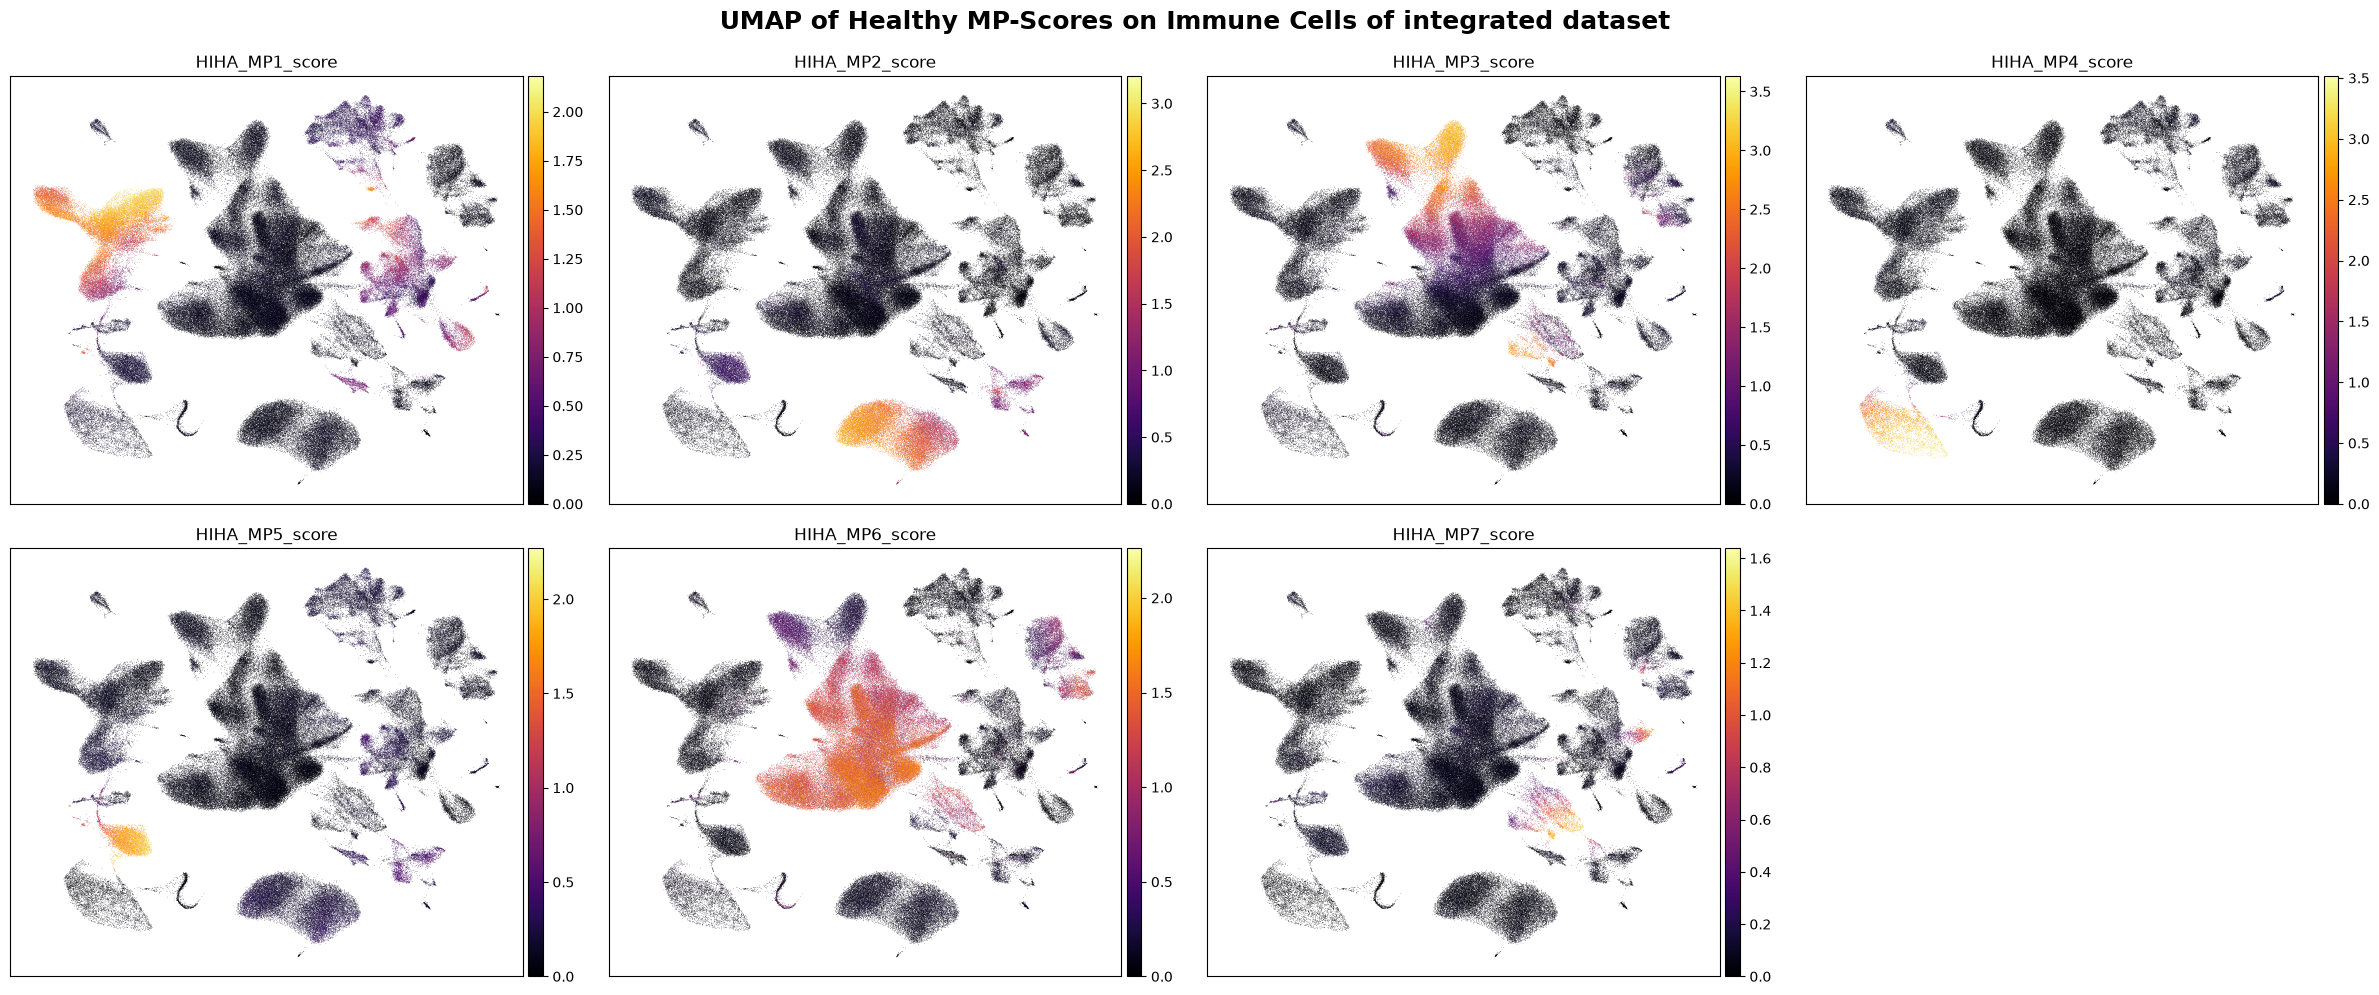

[2026-10-01 17:27:39] PDF saved


In [12]:
def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0

available_mps = [mp for mp in score_cols if mp in adata.obs.columns and adata.obs[mp].notna().any()]
checkpoint(f"\nAvailable MPs: {len(available_mps)}")
checkpoint(f"Available: {available_mps}")

# ALL_MPS = sorted(available_mps, key=mp_sort_key)


checkpoint("Plotting UMAPs")
n_cols = 4  
n_rows = -(-len(SELECTED_MPS) // n_cols)  # ceiling division = 2


fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))  # ← figsize anpassen!
axes = axes.flatten()

fig.suptitle("UMAP of Healthy MP-Scores on Immune Cells of integrated dataset", fontsize=18, fontweight='bold', y=0.99)

for i, mp in enumerate(SELECTED_MPS):
    if mp in adata.obs.columns:
        # vmin/vmax per MP
        mp_vmin = adata.obs[mp].min()
        mp_vmax = adata.obs[mp].max()
        sc.pl.umap(
            adata, 
            color=mp, 
            color_map="inferno", 
            show=False, 
            ax=axes[i], 
            title=mp.replace("_hiha_score", ""),
            vmin=mp_vmin,
            vmax=mp_vmax
        )
        axes[i].set_rasterized(True)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

for j in range(len(SELECTED_MPS), len(axes)):
    axes[j].set_visible(False)


plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_02_umap_grid_healthy_score_on_dataset_SelMP.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")

### UMAP with cells assigned to MP

In [ ]:
HARMONY_REP = "X_pca_harmony"  # adjust if your harmony embedding key differs
MIN_OVERLAP = 0.5  # minimum fraction of an MP's genes that must be present to score it
PERCENTILE_THRESHOLD = 75  

In [21]:
scores_df = adata.obs[score_cols]
 
thresholds = {col: scores_df[col].quantile(PERCENTILE_THRESHOLD / 100) for col in score_cols}
print(f"\nPer-MP {PERCENTILE_THRESHOLD}th percentile thresholds:")
for col, t in thresholds.items():
    print(f"  {col}: {t:.4f}")
 
argmax_mp = scores_df.idxmax(axis=1)
 
passes_threshold = pd.Series(False, index=scores_df.index)
for col in score_cols:
    is_this_mp = argmax_mp == col
    passes_threshold |= is_this_mp & (scores_df[col] >= thresholds[col])
 
dominant_mp = pd.Series("Other", index=adata.obs_names, dtype=object)
dominant_mp.loc[passes_threshold] = argmax_mp[passes_threshold].values
# strip "HIHA_..._score" back down to the bare MP name (e.g. "MP5")
dominant_mp = dominant_mp.str.replace("HIHA_", "", regex=False).str.replace("_score", "", regex=False)
 
mp_order = [mp for mp in MP_PALETTE_HIHA_ALT if mp in mps_to_score]
adata.obs["dominant_MP"] = pd.Categorical(dominant_mp, categories=["Other"] + mp_order)
print("\nDominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts())


Per-MP 75th percentile thresholds:
  HIHA_MP4_score: 0.0690
  HIHA_MP8_score: 0.4454
  HIHA_MP7_score: 0.0670
  HIHA_MP1_score: 0.2538
  HIHA_MP3_score: 0.5435
  HIHA_MP2_score: 0.1547
  HIHA_MP6_score: 1.2050
  HIHA_MP5_score: 0.1432

Dominant MP assignment counts:
dominant_MP
MP6      47987
MP1      43624
Other    40066
MP3      35665
MP2      24889
MP5       6237
MP4       4982
MP7       2028
Name: count, dtype: int64


In [23]:
valid_labels = {"Not scored", "Other"} | set(mp_order)
n_reassigned = (~dominant_mp.isin(valid_labels)).sum()
if n_reassigned:
    reassigned_values = sorted(set(dominant_mp[~dominant_mp.isin(valid_labels)]))
    checkpoint(f"{n_reassigned} cells assigned to an MP not in mp_order "
               f"({reassigned_values}) - moving them to 'Other'")
    dominant_mp = dominant_mp.where(dominant_mp.isin(valid_labels), "Other")
 
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Not scored", "Other"] + mp_order
)
checkpoint("Dominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts(dropna=False))

[2026-09-30 19:13:10] 3467 cells assigned to an MP not in mp_order (['MP8']) - moving them to 'Other'
[2026-09-30 19:13:10] Dominant MP assignment counts:
dominant_MP
MP6           47987
MP1           43624
Other         43533
MP3           35665
MP2           24889
MP5            6237
MP4            4982
MP7            2028
Not scored        0
Name: count, dtype: int64


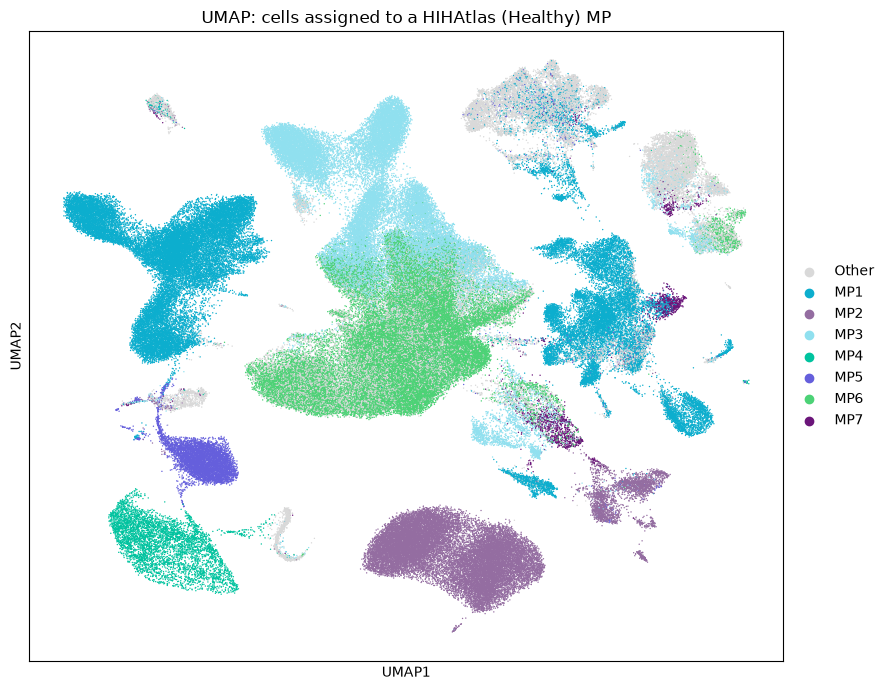

In [25]:
adata.obs["dominant_MP"] = adata.obs["dominant_MP"].cat.remove_unused_categories()

palette = {"Other": "#D9D9D9", **{mp: MP_PALETTE_HIHA_ALT[mp] for mp in mp_order}}
adata.uns["dominant_MP_colors"] = [palette[c] for c in adata.obs["dominant_MP"].cat.categories]
 
fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(
    adata,
    color="dominant_MP",
    ax=ax,
    show=False,
    size=4,
    title="UMAP: cells assigned to a HIHAtlas (Healthy) MP",
)
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "10_02_umap_dominant_MP.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
 

### Violin plot grid: HIHA_MP scores per celltype

In [11]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

In [63]:
score_cols = sorted(
    [c for c in adata.obs.columns if re.match(r"(HIHA_)?MP\d+_score$", c)],
    key=lambda c: int(re.search(r"\d+", c).group())
)
score_cols = [c for c in score_cols if not re.match(r"(HIHA_)?MP8_score$", c)]
print("Detected MP score columns:", score_cols)
assert len(score_cols) > 0, (
    "No MP score columns matched. Print adata.obs.columns and check the "
    "actual naming from your scoring step, then adjust the regex above."
)

def display_mp(mp_name):
    """HIHA_MP1 -> Healthy MP1 for anything user-facing (titles, labels, sheet names)."""
    return mp_name.replace("HIHA_MP", "Healthy MP")

Detected MP score columns: ['HIHA_MP1_score', 'HIHA_MP2_score', 'HIHA_MP3_score', 'HIHA_MP4_score', 'HIHA_MP5_score', 'HIHA_MP6_score', 'HIHA_MP7_score']


In [64]:
celltype_order = list(pd.Categorical(adata.obs["decoupler_level1_celltype"]).categories)
 
label_map = {"HIHAtlas": "Healthy", "GBMap": "GBM"}
adata.obs["condition"] = adata.obs["dataset"].map(label_map)
condition_order = ["Healthy", "GBM"]
condition_palette = {"Healthy": "#69DD82", "GBM": "#CA425F"}
 
df = adata.obs[score_cols + ["decoupler_level1_celltype", "condition"]].copy()
df["decoupler_level1_celltype"] = pd.Categorical(
    df["decoupler_level1_celltype"], categories=celltype_order, ordered=True
)
df["condition"] = pd.Categorical(df["condition"], categories=condition_order, ordered=True)
 
MIN_CELLS = 10  # skip / flag groups too small for a meaningful violin
 


In [65]:
# ---- 3. one figure per MP, 5x5 grid of cell types ----
for score_col in score_cols:
    mp_name = score_col.replace("_score", "")
    fig, axes = plt.subplots(5, 5, figsize=(25, 20))
    axes = axes.flatten()
 
    for ax, ct in zip(axes, celltype_order):
        sub = df[df["decoupler_level1_celltype"] == ct]
        counts = sub["condition"].value_counts()
        low_n = counts.reindex(condition_order).fillna(0) < MIN_CELLS
 
        if sub.empty or low_n.all():
            ax.set_visible(False)
            continue
 
        sns.violinplot(
            data=sub, x="condition", y=score_col, hue = "condition",
            order=condition_order, palette=condition_palette,
            ax=ax, cut=0, inner="quartile", width=0.5,
        )
        ax.set_title(ct, fontsize=11)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5))

        # annotate n per group; flag low-n groups instead of hiding them,
        # since a missing panel is easy to misread as "no cells"
        for i, cond in enumerate(condition_order):
            n = int(counts.get(cond, 0))
            label = f"n={n}" + (" (low n)" if n < MIN_CELLS else "")
            ax.text(i, -0.10, label, ha="center", va="top", fontsize=7, transform=ax.get_xaxis_transform())
 
    for ax in axes[len(celltype_order):]:
        ax.set_visible(False)
 
    fig.suptitle(f"{mp_name} score: Healthy vs GBM, per cell type", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(os.path.join(OUT_DIR, f"{mp_name}_violin_by_celltype.pdf"))
    plt.close(fig)
    print(f"Saved {mp_name}_violin_by_celltype.pdf")
 
print("Done.")

Saved HIHA_MP1_violin_by_celltype.pdf
Saved HIHA_MP2_violin_by_celltype.pdf
Saved HIHA_MP3_violin_by_celltype.pdf
Saved HIHA_MP4_violin_by_celltype.pdf
Saved HIHA_MP5_violin_by_celltype.pdf
Saved HIHA_MP6_violin_by_celltype.pdf
Saved HIHA_MP7_violin_by_celltype.pdf
Done.


### Wilcoxon rank-sum test (Mann-Whitney U test)

In [32]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

In [66]:
results = []
for score_col in score_cols:
    mp_name = score_col.replace("_score", "")
    for ct in celltype_order:
        sub = adata.obs.loc[adata.obs["decoupler_level1_celltype"] == ct]
        healthy = sub.loc[sub["condition"] == "Healthy", score_col].dropna()
        gbm = sub.loc[sub["condition"] == "GBM", score_col].dropna()
        n_healthy, n_gbm = len(healthy), len(gbm)
 
        if n_healthy < MIN_CELLS or n_gbm < MIN_CELLS:
            note = "no Healthy cells" if n_healthy == 0 else \
                   "no GBM cells" if n_gbm == 0 else "low n - excluded"
            results.append(dict(mp=mp_name, celltype=ct, n_healthy=n_healthy,
                                 n_gbm=n_gbm, mean_diff=np.nan, pvalue=np.nan, note=note))
            continue
 
        _, p = mannwhitneyu(healthy, gbm, alternative="two-sided")
        results.append(dict(
            mp=mp_name, celltype=ct, n_healthy=n_healthy, n_gbm=n_gbm,
            mean_diff=healthy.mean() - gbm.mean(), pvalue=p, note="",
        ))
 
res_df = pd.DataFrame(results)

In [67]:
# FDR correction across all celltypes tested for given MP

res_df["padj"] = np.nan
for mp_name, idx in res_df.groupby("mp").groups.items():
    valid = res_df.loc[idx, "pvalue"].notna()
    if valid.sum() > 0:
        res_df.loc[idx[valid], "padj"] = multipletests(
            res_df.loc[idx[valid], "pvalue"], method="fdr_bh"
        )[1]
 

In [68]:
# filter to significant hits (padj < 0.05), then rank by raw mean difference (Healthy-GBM) within each MP

ALPHA = 0.05
res_df["significant"] = res_df["padj"] < ALPHA
res_df["abs_mean_diff"] = res_df["mean_diff"].abs()
 
res_df["rank_in_mp"] = np.nan
sig_mask = res_df["significant"]
res_df.loc[sig_mask, "rank_in_mp"] = res_df.loc[sig_mask].groupby("mp")["abs_mean_diff"].rank(
    ascending=False, method="min"
)
res_df = res_df.sort_values(["mp", "rank_in_mp"])
 
 
out_csv = os.path.join(OUT_DIR, "10_02_mp_celltype_ranking.csv")
res_df.to_csv(out_csv, index=False)
print(f"Full results saved to {out_csv}")

Full results saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_02_mp_celltype_ranking.csv


In [69]:
excluded = res_df[res_df["note"] != ""][["mp", "celltype", "n_healthy", "n_gbm", "note"]]
if not excluded.empty:
    print("\nExcluded from ranking (insufficient cells on one side):")
    print(excluded.drop_duplicates(subset="celltype").to_string(index=False))
 
print("\nTop 5 significant cell types per MP (padj<0.05), ranked by |mean difference|:")
top5 = res_df[res_df["rank_in_mp"] <= 5]
print(top5[["mp", "celltype", "mean_diff", "padj", "n_healthy", "n_gbm"]].to_string(index=False))


Excluded from ranking (insufficient cells on one side):
      mp         celltype  n_healthy  n_gbm             note
HIHA_MP1 Macrophages SPP1          0   5000 no Healthy cells
HIHA_MP1       Mast cells          0    639 no Healthy cells

Top 5 significant cell types per MP (padj<0.05), ranked by |mean difference|:
      mp                 celltype  mean_diff          padj  n_healthy  n_gbm
HIHA_MP1                      mDC   0.842384  0.000000e+00       1921   5000
HIHA_MP1                      cDC   0.805672  0.000000e+00       2292   3169
HIHA_MP1                Monocytes   0.452634  0.000000e+00      10528   5000
HIHA_MP1 Macro. and mono. prolif.   0.446768  0.000000e+00       4067   5000
HIHA_MP1                TAMs C1QC   0.434283 2.131913e-178       1852   5000
HIHA_MP2    B cells proliferative   1.330155 4.709613e-141       2437    414
HIHA_MP2                      pDC   0.868163  0.000000e+00       8738   2715
HIHA_MP2                  B cells   0.728376  0.000000e+00      1

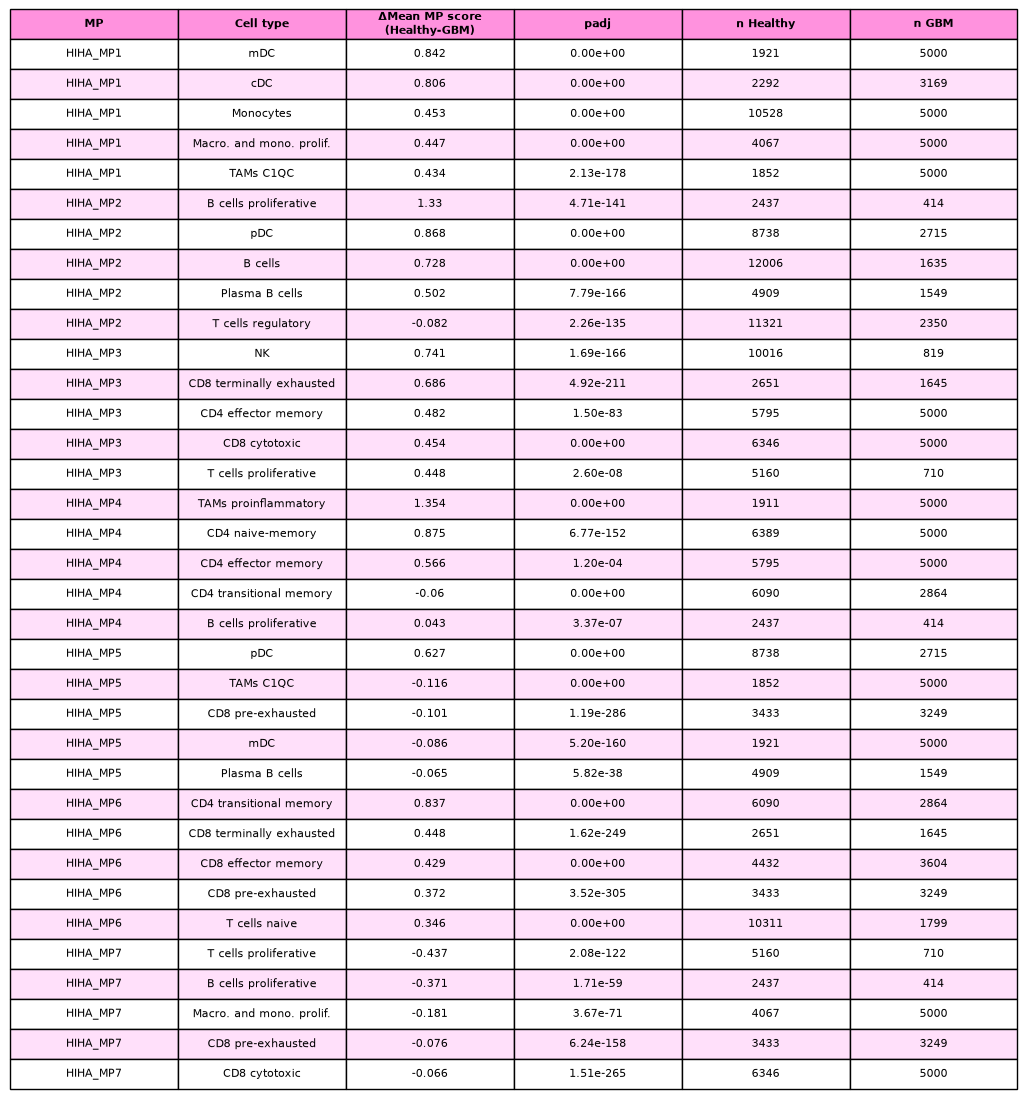

Top-5-per-MP summary table saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_02_mp_celltype_top5_summary.pdf


In [70]:
summary = top5[["mp", "celltype", "mean_diff", "padj", "n_healthy", "n_gbm"]].copy()
summary["mean_diff"] = summary["mean_diff"].round(3)
summary["padj"] = summary["padj"].apply(lambda x: f"{x:.2e}")
 
fig, ax = plt.subplots(figsize=(13, 0.35 * len(summary) + 1))
ax.axis("off")
tbl = ax.table(
    cellText=summary.values,
    colLabels=["MP", "Cell type", "ΔMean MP score\n(Healthy-GBM)", "padj", "n Healthy", "n GBM"],
    cellLoc="center", loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.8)

# bold the header row, alternate row shading for readability
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#FF92DE")
    elif row % 2 == 0:
        cell.set_facecolor("#FFE0FA")


pdf_path = os.path.join(OUT_DIR, "10_02_mp_celltype_top5_summary.pdf")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
print(f"Top-5-per-MP summary table saved to {pdf_path}")

### Lollipop / rank plot the mean differences of Top5 celltype per MP

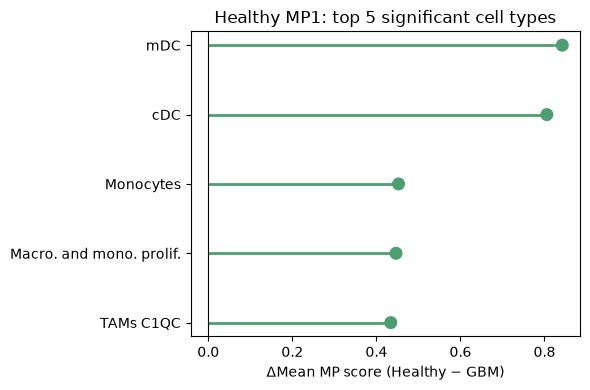

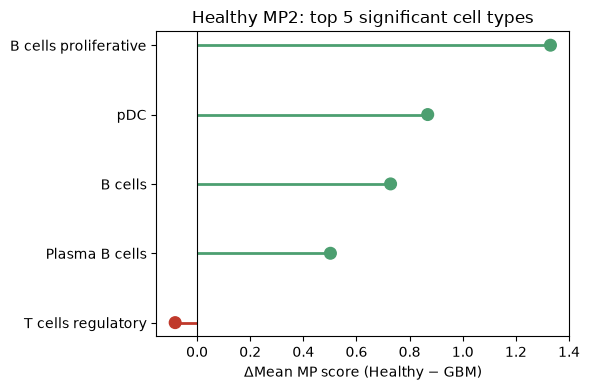

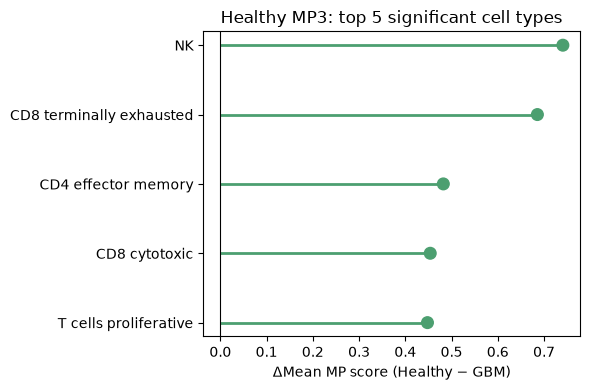

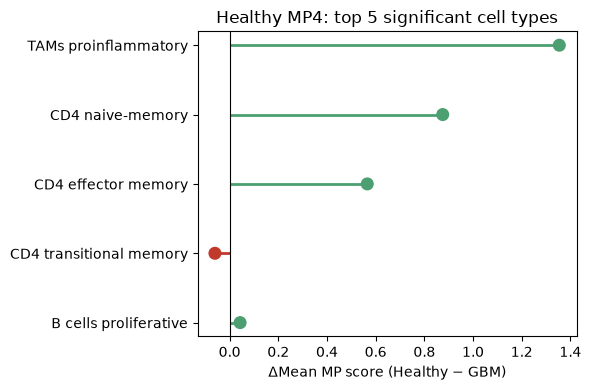

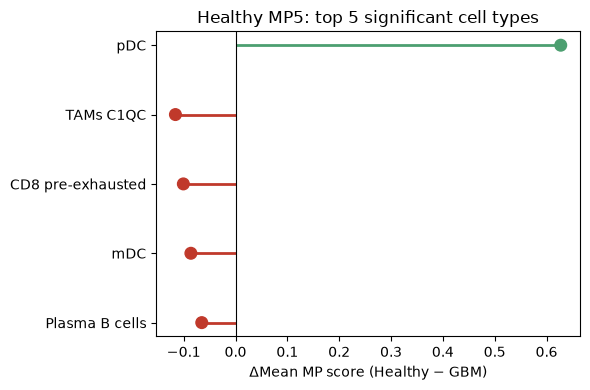

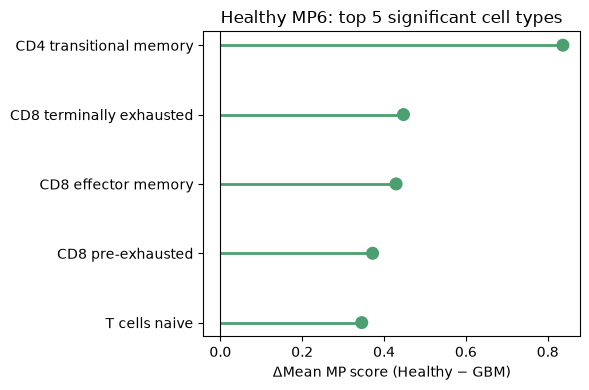

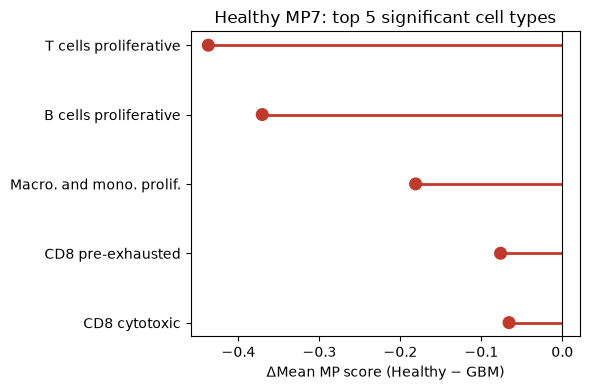

Rank plots (top 5 per MP, one page per MP) saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/10_integration_GBM_HIHA/10_02_lollipop_mp_rank_top5_all.pdf


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
 
rank_pdf_path = os.path.join(OUT_DIR, "10_02_lollipop_mp_rank_top5_all.pdf")
with PdfPages(rank_pdf_path) as pdf:
    for mp_name, sub in top5.groupby("mp"):
        sub = sub.sort_values("abs_mean_diff", ascending=True)  # # largest |diff| at top of plot
        colors = ["#4C9F70" if v > 0 else "#C0392B" for v in sub["mean_diff"]]
 
        fig, ax = plt.subplots(figsize=(6, 0.6 * len(sub) + 1))
        ax.hlines(y=sub["celltype"], xmin=0, xmax=sub["mean_diff"], color=colors, linewidth=2)
        ax.scatter(sub["mean_diff"], sub["celltype"], color=colors, s=70, zorder=3)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_xlabel("ΔMean MP score (Healthy − GBM)")
        ax.set_title(f"{display_mp(mp_name)}: top 5 significant cell types")
        fig.tight_layout()
        pdf.savefig(fig, bbox_inches="tight")
        plt.show(fig)
        plt.close(fig)
 
print(f"Rank plots (top 5 per MP, one page per MP) saved to {rank_pdf_path}")